In [1]:
# Imports + setup

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")

# tree model + shap
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    from sklearn.ensemble import RandomForestRegressor
    HAS_XGB = False

import shap

OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 11
np.random.seed(42)

In [ ]:
# DB-native Feature Engineering

import numpy as np
import pandas as pd
import psycopg2

# db config
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "dbname": "capstone_170b",
    "user": "postgres",
    "password": "password"
}

# settings
START = "2005-01-01"
END   = "2024-12-31"

# helpers
def monthly_log_return(level_series):
    m = level_series.resample("ME").last()
    return np.log(m / m.shift(1))

# 1) load tables from postgres
conn = psycopg2.connect(**DB_CONFIG)

market_raw = pd.read_sql(
    """
    SELECT trade_date, ticker, adj_close
    FROM market_raw
    WHERE trade_date BETWEEN %(start)s AND %(end)s
      AND ticker IN ('SPY', '^VIX', 'FXI', 'CL=F')
    ORDER BY trade_date, ticker
    """,
    conn,
    params={"start": START, "end": END}
)

macro = pd.read_sql(
    """
    SELECT observation_date, series_id, value
    FROM macro_observations
    WHERE observation_date BETWEEN %(start)s AND %(end)s
      AND series_id IN ('CPIAUCSL', 'UNRATE', 'GACDFSA066MSFRBPHI','DGS10')
    ORDER BY observation_date, series_id
    """,
    conn,
    params={"start": START, "end": END}
)

fomc = pd.read_sql(
    """
    SELECT meeting_date, hawkish_score
    FROM fomc_minutes
    WHERE meeting_date BETWEEN %(start)s AND %(end)s
    ORDER BY meeting_date
    """,
    conn,
    params={"start": START, "end": END}
)

conn.close()

# 2) rebuild market price
market_raw["trade_date"] = pd.to_datetime(market_raw["trade_date"])
market_raw["adj_close"] = pd.to_numeric(market_raw["adj_close"], errors="coerce")

px_adj = (
    market_raw
    .pivot(index="trade_date", columns="ticker", values="adj_close")
    .sort_index()
)

px_adj.index.name = "trade_date"

# individual series
spy_adj = px_adj["SPY"].dropna() if "SPY" in px_adj.columns else pd.Series(dtype=float)
vix_lvl = px_adj["^VIX"].dropna() if "^VIX" in px_adj.columns else pd.Series(dtype=float)
fxi_adj = px_adj["FXI"].dropna() if "FXI" in px_adj.columns else pd.Series(dtype=float)
oil_lvl = px_adj["CL=F"].dropna() if "CL=F" in px_adj.columns else pd.Series(dtype=float)

# target
spy_mret = monthly_log_return(spy_adj).rename("spy_log_ret_m")

# Quarterly Pivot target
spy_m = spy_adj.resample("ME").last()
spy_3m_fwd = np.log(spy_m.shift(-3) / spy_m).rename("spy_log_ret_3m_fwd")

# market features
vix_m = vix_lvl.resample("ME").last().rename("vix_m")
log_vix_m = np.log(vix_m).rename("log_vix_m")

# Quarterly Pivot smoothing
vix_3ma = vix_m.rolling(3, min_periods=1).mean().rename("vix_3ma")
log_vix_3ma = log_vix_m.rolling(3, min_periods=1).mean().rename("log_vix_3ma")

fxi_mret = monthly_log_return(fxi_adj).rename("fxi_log_ret_m")
oil_mret = monthly_log_return(oil_lvl).rename("oil_log_ret_m")

# momentum control
spy_m = spy_adj.resample("ME").last()
mom_3m = np.log(spy_m / spy_m.shift(3)).rename("mom_3m_log")
mom_3m_lag1 = mom_3m.shift(1).rename("mom_3m_log_lag1")

# 3) rebuild macro features
macro["observation_date"] = pd.to_datetime(macro["observation_date"])
macro["value"] = pd.to_numeric(macro["value"], errors="coerce")

macro_wide = (
    macro
    .pivot(index="observation_date", columns="series_id", values="value")
    .sort_index()
)

macro_m = macro_wide.resample("ME").last()

# match old naming
cpi = macro_m["CPIAUCSL"].rename("cpi_idx") if "CPIAUCSL" in macro_m.columns else None
unr = macro_m["UNRATE"].rename("unrate") if "UNRATE" in macro_m.columns else None
dgs = macro_m["DGS10"].rename("dgs10") if "DGS10" in macro_m.columns else None
pmi = macro_m["GACDFSA066MSFRBPHI"].rename("pmi") if "GACDFSA066MSFRBPHI" in macro_m.columns else None
pmi_id = "GACDFSA066MSFRBPHI" if pmi is not None else None

# transformations
cpi_yoy = (cpi.pct_change(12) * 100.0).rename("cpi_yoy_pct") if cpi is not None else None
unrate  = unr.rename("unrate") if unr is not None else None
dgs10   = dgs.rename("dgs10") if dgs is not None else None
pmi     = pmi.rename("pmi") if pmi is not None else None

# 4) rebuild fomc sentiment
full_index = spy_mret.index
fomc_sent = pd.Series(index=full_index, data=np.nan, name="fomc_hawk_proxy_m")
fomc_3ma = fomc_sent.rolling(3, min_periods=1).mean().rename("fomc_hawk_proxy_3ma")

if len(fomc) > 0:
    fomc["meeting_date"] = pd.to_datetime(fomc["meeting_date"])
    fomc["hawkish_score"] = pd.to_numeric(fomc["hawkish_score"], errors="coerce")
    fomc = fomc.dropna(subset=["meeting_date"])

    fomc["month_end"] = fomc["meeting_date"].dt.to_period("M").dt.to_timestamp("M")

    sent = (
        fomc.groupby("month_end")["hawkish_score"]
        .mean()
        .rename("fomc_hawk_proxy_m")
    )

    fomc_sent = sent.reindex(full_index).ffill()
    fomc_3ma = fomc_sent.rolling(3, min_periods=1).mean().rename("fomc_hawk_proxy_3ma")

# 5) build final engineered dataset
cols = [
    spy_mret,
    spy_3m_fwd,
    mom_3m_lag1,
    vix_3ma.shift(1).rename("vix_3ma_lag1"),
    log_vix_3ma.shift(1).rename("log_vix_3ma_lag1"),
    fxi_mret.shift(1).rename("fxi_log_ret_m_lag1"),
    oil_mret.shift(1).rename("oil_log_ret_m_lag1"),
    fomc_3ma.shift(1).rename("fomc_hawk_proxy_3ma_lag1"),
]

if cpi_yoy is not None:
    cols.append(cpi_yoy.shift(1).rename("cpi_yoy_pct_lag1"))
if unrate is not None:
    cols.append(unrate.shift(1).rename("unrate_lag1"))
if dgs10 is not None:
    cols.append(dgs10.shift(1).rename("dgs10_lag1"))
if pmi is not None:
    cols.append(pmi.shift(1).rename("pmi_lag1"))

engineered = pd.concat(cols, axis=1).dropna(subset=["spy_log_ret_m", "spy_log_ret_3m_fwd"]).reset_index()
engineered = engineered.rename(columns={"index": "month_end"})
engineered["month_end"] = pd.to_datetime(engineered["month_end"])

print("Engineered dataset built from Postgres.")
print("Rows:", len(engineered))
print("Columns:", list(engineered.columns))
print("PMI series used:", pmi_id)
print()
print("Loaded tables:")
print("market_raw rows used:", len(market_raw))
print("macro rows used:", len(macro))
print("fomc rows used:", len(fomc))

Engineered dataset built from Postgres.
Rows: 236
Columns: ['month_end', 'spy_log_ret_m', 'spy_log_ret_3m_fwd', 'mom_3m_log_lag1', 'vix_3ma_lag1', 'log_vix_3ma_lag1', 'fxi_log_ret_m_lag1', 'oil_log_ret_m_lag1', 'fomc_hawk_proxy_3ma_lag1', 'cpi_yoy_pct_lag1', 'unrate_lag1', 'dgs10_lag1', 'pmi_lag1']
PMI series used: GACDFSA066MSFRBPHI

Loaded tables:
market_raw rows used: 20125
macro rows used: 5724
fomc rows used: 138


In [3]:
# Prepare modeling data

df = engineered.copy()

# make sure month_end is datetime and sorted
df["month_end"] = pd.to_datetime(df["month_end"])
df = df.sort_values("month_end").reset_index(drop=True)

target_col = "spy_log_ret_3m_fwd"

# choose the feature columns that actually exist
candidate_features = [
    "mom_3m_log_lag1",
    "vix_3ma_lag1",
    "log_vix_3ma_lag1",
    "fxi_log_ret_m_lag1",
    "oil_log_ret_m_lag1",
    "fomc_hawk_proxy_3ma_lag1",
    "cpi_yoy_pct_lag1",
    "unrate_lag1",
    "dgs10_lag1",
    "pmi_lag1",
]

feature_cols = [c for c in candidate_features if c in df.columns]

# keep only rows with target present
df = df.dropna(subset=[target_col]).copy()

# for modeling, drop rows where all features are missing
df = df.dropna(subset=feature_cols, how="all").copy()

print("Rows:", len(df))
print("Target:", target_col)
print("Features used:", feature_cols)

Rows: 236
Target: spy_log_ret_3m_fwd
Features used: ['mom_3m_log_lag1', 'vix_3ma_lag1', 'log_vix_3ma_lag1', 'fxi_log_ret_m_lag1', 'oil_log_ret_m_lag1', 'fomc_hawk_proxy_3ma_lag1', 'cpi_yoy_pct_lag1', 'unrate_lag1', 'dgs10_lag1', 'pmi_lag1']


In [5]:
# ROLLING ELASTIC NET

WINDOW = 36 # 3 years of monthly data
MIN_NONMISSING_FEATURES = 3

results = []
coef_rows = [] # Elastic Net coefficients over time
shap_rows = [] # SHAP values over time for nonlinear model

# helper: metrics later
def sign_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# iterate so each month after the first 36 gets predicted from the previous 36 months
for t in range(WINDOW, len(df)):
    train = df.iloc[t-WINDOW:t].copy()
    test = df.iloc[[t]].copy()

    # use only features that exist and are not too missing inside this training window
    usable = []
    for c in feature_cols:
        if train[c].notna().sum() >= MIN_NONMISSING_FEATURES:
            usable.append(c)

    if len(usable) == 0:
        continue

    # drop rows with missing features for model-fitting
    train_full = train.dropna(subset=usable).copy()
    test_full = test.dropna(subset=usable).copy()

    # if the current month has missing features, skip prediction
    if len(test_full) == 0:
        continue

    # if too few training rows remain after dropping NA, skip
    if len(train_full) < 18:
        continue

    X_train = train_full[usable]
    y_train = train_full[target_col].values
    X_test = test_full[usable]
    y_test = test_full[target_col].values[0]

    pred_dict = {
        "month_end": test_full["month_end"].iloc[0],
        "actual": y_test,
    }

    # 1) Baseline: rolling historical mean
    pred_mean = float(np.mean(y_train))
    pred_dict["pred_mean"] = pred_mean

    # 2) Baseline: momentum-only linear regression
    if "mom_3m_log_lag1" in usable:
        mom_train = train_full[["mom_3m_log_lag1"]]
        mom_test = test_full[["mom_3m_log_lag1"]]

        lr_mom = LinearRegression()
        lr_mom.fit(mom_train, y_train)
        pred_dict["pred_mom_lr"] = float(lr_mom.predict(mom_test)[0])
    else:
        pred_dict["pred_mom_lr"] = np.nan

    # 3) Rolling Elastic Net

    n_train = len(train_full)
    n_splits = min(3, max(2, n_train // 10))

    enet_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(
            l1_ratio=[0.5, 0.7, 0.9], # focus on sparse models
            alphas=np.logspace(-2, 0.5, 25), # tighter range
            cv=TimeSeriesSplit(n_splits=n_splits),
            max_iter=50000,
            tol=1e-4,
            random_state=42
        ))
    ])

    enet_pipe.fit(X_train, y_train)
    pred_dict["pred_enet"] = float(enet_pipe.predict(X_test)[0])

    # store coefficients for heatmap
    enet_model = enet_pipe.named_steps["enet"]
    coef_map = {"month_end": test_full["month_end"].iloc[0]}
    for f, coef in zip(usable, enet_model.coef_):
        coef_map[f] = coef
    coef_rows.append(coef_map)

In [6]:
# SHAP Nonlinear model, Quarterly Pivot

WINDOW = 60 # 5 years of monthly data
STRIDE = 3  # Quarterly Pivot: move forward 3 months at a time
CV_GAP = 2 # avoid leakage when tuning a 3-month-forward target
MIN_NONMISSING_FEATURES = 3

results = []
coef_rows = [] # Elastic Net coefficients over time
shap_rows = [] # SHAP values over time for nonlinear model

# helper: metrics later
def sign_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# Quarterly Pivot: predict the next 3-month return, then move forward 3 months.
# The final 3 rows were already removed when target_col was set to spy_log_ret_3m_fwd.
for t in range(WINDOW, len(df), STRIDE):
    train = df.iloc[t-WINDOW:t].copy()
    test = df.iloc[[t]].copy()

    # use only features that exist and are not too missing inside this training window
    usable = []
    for c in feature_cols:
        if train[c].notna().sum() >= MIN_NONMISSING_FEATURES:
            usable.append(c)

    if len(usable) == 0:
        continue

    # drop rows with missing features for model-fitting
    train_full = train.dropna(subset=usable).copy()
    test_full = test.dropna(subset=usable).copy()

    # if the current month has missing features, skip prediction
    if len(test_full) == 0:
        continue

    # if too few training rows remain after dropping NA, skip
    if len(train_full) < 18:
        continue

    X_train = train_full[usable]
    y_train = train_full[target_col].values
    X_test = test_full[usable]
    y_test = test_full[target_col].values[0]

    pred_dict = {
        "month_end": test_full["month_end"].iloc[0],
        "actual": y_test,
    }

    # 1) Baseline: rolling historical mean
    pred_mean = float(np.mean(y_train))
    pred_dict["pred_mean"] = pred_mean

    # 2) Baseline: momentum-only linear regression
    if "mom_3m_log_lag1" in usable:
        mom_train = train_full[["mom_3m_log_lag1"]]
        mom_test = test_full[["mom_3m_log_lag1"]]

        lr_mom = LinearRegression()
        lr_mom.fit(mom_train, y_train)
        pred_dict["pred_mom_lr"] = float(lr_mom.predict(mom_test)[0])
    else:
        pred_dict["pred_mom_lr"] = np.nan

    # 3) Rolling Elastic Net
    # Use time-series CV inside each rolling training window
    from sklearn.model_selection import GridSearchCV
    from sklearn.metrics import r2_score, mean_squared_error

    n_train = len(train_full)
    n_splits = min(3, max(2, n_train // 10))

    enet_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(
            l1_ratio=[0.5, 0.7, 0.9], # focus on sparse models
            alphas=np.logspace(-2, 0.5, 25), # tighter range
            cv=TimeSeriesSplit(n_splits=n_splits, gap=CV_GAP),
            max_iter=50000,
            tol=1e-4,
            random_state=42
        ))
    ])

    enet_pipe.fit(X_train, y_train)
    pred_dict["pred_enet"] = float(enet_pipe.predict(X_test)[0])

    # store coefficients for heatmap
    enet_model = enet_pipe.named_steps["enet"]
    coef_map = {"month_end": test_full["month_end"].iloc[0]}
    for f, coef in zip(usable, enet_model.coef_):
        coef_map[f] = coef
    coef_rows.append(coef_map)

    # 4) Rolling nonlinear model (XGB preferred, else RF)
    if HAS_XGB:
        base_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=4)
        param_grid = {
            'max_depth': [1, 2],
            'n_estimators': [50, 75, 100],
            'min_child_weight': [5, 8, 10],
            'learning_rate': [0.01, 0.03, 0.05]
            }
    else:
        base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
        param_grid = {
            'max_depth': [1, 2],
            'n_estimators': [50, 75, 100],
            'min_samples_leaf': [5, 8, 10]
            }

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=TimeSeriesSplit(n_splits=5, gap=CV_GAP),
        scoring='r2',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    tree_model = grid_search.best_estimator_
    pred_tree = float(tree_model.predict(X_test)[0])
    pred_dict["pred_tree"] = pred_tree

    # 1) capture best hyperparameters
    pred_dict["best_params"] = str(grid_search.best_params_)
    pred_dict["best_depth"] = grid_search.best_params_.get('max_depth')
    pred_dict["best_n_estimators"] = grid_search.best_params_.get('n_estimators')

    # 2) training metrics
    train_preds = tree_model.predict(X_train)
    pred_dict["train_r2"] = r2_score(y_train, train_preds)
    pred_dict["train_mse"] = mean_squared_error(y_train, train_preds)

    # 3) validation metrics
    pred_dict["val_r2_cv"] = grid_search.best_score_

    # 4) testing metrics (Squared Error for this month)
    pred_dict["test_mse"] = (y_test - pred_tree)**2


    # SHAP values for the single predicted month
    try:
        explainer = shap.TreeExplainer(tree_model)
        shap_exp = explainer(X_test)

        row = {"month_end": test_full["month_end"].iloc[0]}
        for f, sv in zip(usable, shap_exp.values[0]):
            row[f] = float(sv)
        shap_rows.append(row)

    except Exception as e:
        print("SHAP failed for", test_full["month_end"].iloc[0], ":", e)


    results.append(pred_dict)

rolling_preds = pd.DataFrame(results).sort_values("month_end").reset_index(drop=True)
coef_df = pd.DataFrame(coef_rows).sort_values("month_end").reset_index(drop=True)
shap_df = pd.DataFrame(shap_rows).sort_values("month_end").reset_index(drop=True)

print("Prediction rows:", len(rolling_preds))
print("Coefficient rows:", len(coef_df))
print("SHAP rows:", len(shap_df))
print("Tree model used:", "XGBoost" if HAS_XGB else "RandomForest")

Prediction rows: 59
Coefficient rows: 59
SHAP rows: 59
Tree model used: XGBoost


In [7]:
# Create the diagnostic dataframe once the loop is done
rolling_preds = pd.DataFrame(results).sort_values("month_end").reset_index(drop=True)

# Calculate the gap to identify overfitting
rolling_preds['overfit_gap'] = rolling_preds['train_r2'] - rolling_preds['val_r2_cv']

print("--- Rolling Window Diagnostics ---")
print(f"Average Training R^2:   {rolling_preds['train_r2'].mean():.4f}")
print(f"Average Validation R^2: {rolling_preds['val_r2_cv'].mean():.4f}")
print(f"Average Overfit Gap:    {rolling_preds['overfit_gap'].mean():.4f}")
print("-" * 30)

print("Hyperparameter Distribution:")
print(rolling_preds['best_params'].value_counts(normalize=True).head())

--- Rolling Window Diagnostics ---
Average Training R^2:   0.4663
Average Validation R^2: -1.5364
Average Overfit Gap:    2.0026
------------------------------
Hyperparameter Distribution:
best_params
{'learning_rate': 0.05, 'max_depth': 1, 'min_child_weight': 5, 'n_estimators': 100}    0.118644
{'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 50}     0.118644
{'learning_rate': 0.01, 'max_depth': 1, 'min_child_weight': 10, 'n_estimators': 50}    0.084746
{'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 100}    0.067797
{'learning_rate': 0.03, 'max_depth': 1, 'min_child_weight': 5, 'n_estimators': 50}     0.050847
Name: proportion, dtype: float64


In [8]:
print(rolling_preds[["month_end", "pred_mean", "pred_tree"]].head(10))
print((rolling_preds["pred_tree"] - rolling_preds["pred_mean"]).abs().describe())
print(shap_df.head())
print(shap_df.drop(columns="month_end").abs().sum().sum())
print(tree_model.feature_importances_)

   month_end  pred_mean  pred_tree
0 2010-02-28  -0.018851   0.054451
1 2010-05-31  -0.023591  -0.053583
2 2010-08-31  -0.016902   0.060668
3 2010-11-30  -0.006793   0.070860
4 2011-02-28  -0.000065   0.021510
5 2011-05-31  -0.000795  -0.010858
6 2011-08-31  -0.006683  -0.027105
7 2011-11-30  -0.002325   0.060331
8 2012-02-29   0.003403   0.034849
9 2012-05-31   0.001802   0.005684
count    59.000000
mean      0.018091
std       0.020555
min       0.000063
25%       0.004014
50%       0.010449
75%       0.023546
max       0.077653
dtype: float64
   month_end  mom_3m_log_lag1  vix_3ma_lag1  log_vix_3ma_lag1  \
0 2010-02-28         0.000000      0.000000               0.0   
1 2010-05-31         0.000000     -0.034552               0.0   
2 2010-08-31         0.000000      0.013610               0.0   
3 2010-11-30         0.000000     -0.003389               0.0   
4 2011-02-28        -0.005685     -0.051703               0.0   

   fxi_log_ret_m_lag1  oil_log_ret_m_lag1  fomc_hawk_prox

   month_end          feature  shap_value  abs_shap
0 2010-02-28  mom_3m_log_lag1    0.000000  0.000000
1 2010-05-31  mom_3m_log_lag1    0.000000  0.000000
2 2010-08-31  mom_3m_log_lag1    0.000000  0.000000
3 2010-11-30  mom_3m_log_lag1    0.000000  0.000000
4 2011-02-28  mom_3m_log_lag1   -0.005685  0.005685
(590, 4)
                    feature  abs_shap
8               unrate_lag1  0.008838
9              vix_3ma_lag1  0.007791
0          cpi_yoy_pct_lag1  0.006686
1                dgs10_lag1  0.004184
6        oil_log_ret_m_lag1  0.003820
2  fomc_hawk_proxy_3ma_lag1  0.003079
5           mom_3m_log_lag1  0.002456
7                  pmi_lag1  0.001318
3        fxi_log_ret_m_lag1  0.001210
4          log_vix_3ma_lag1  0.000494


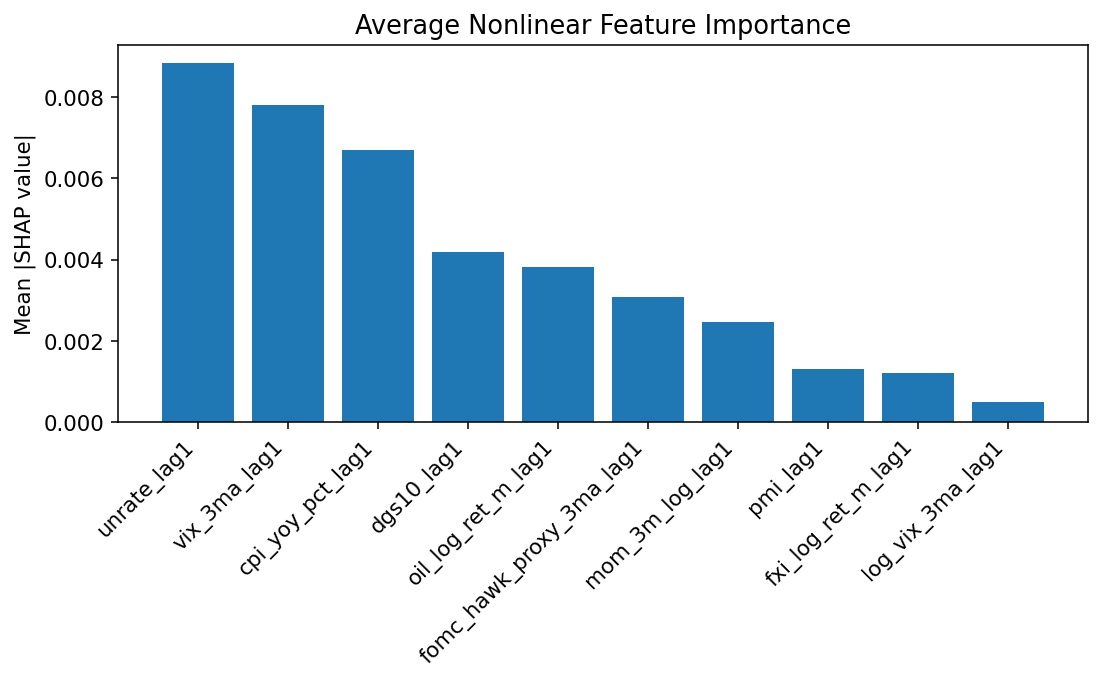

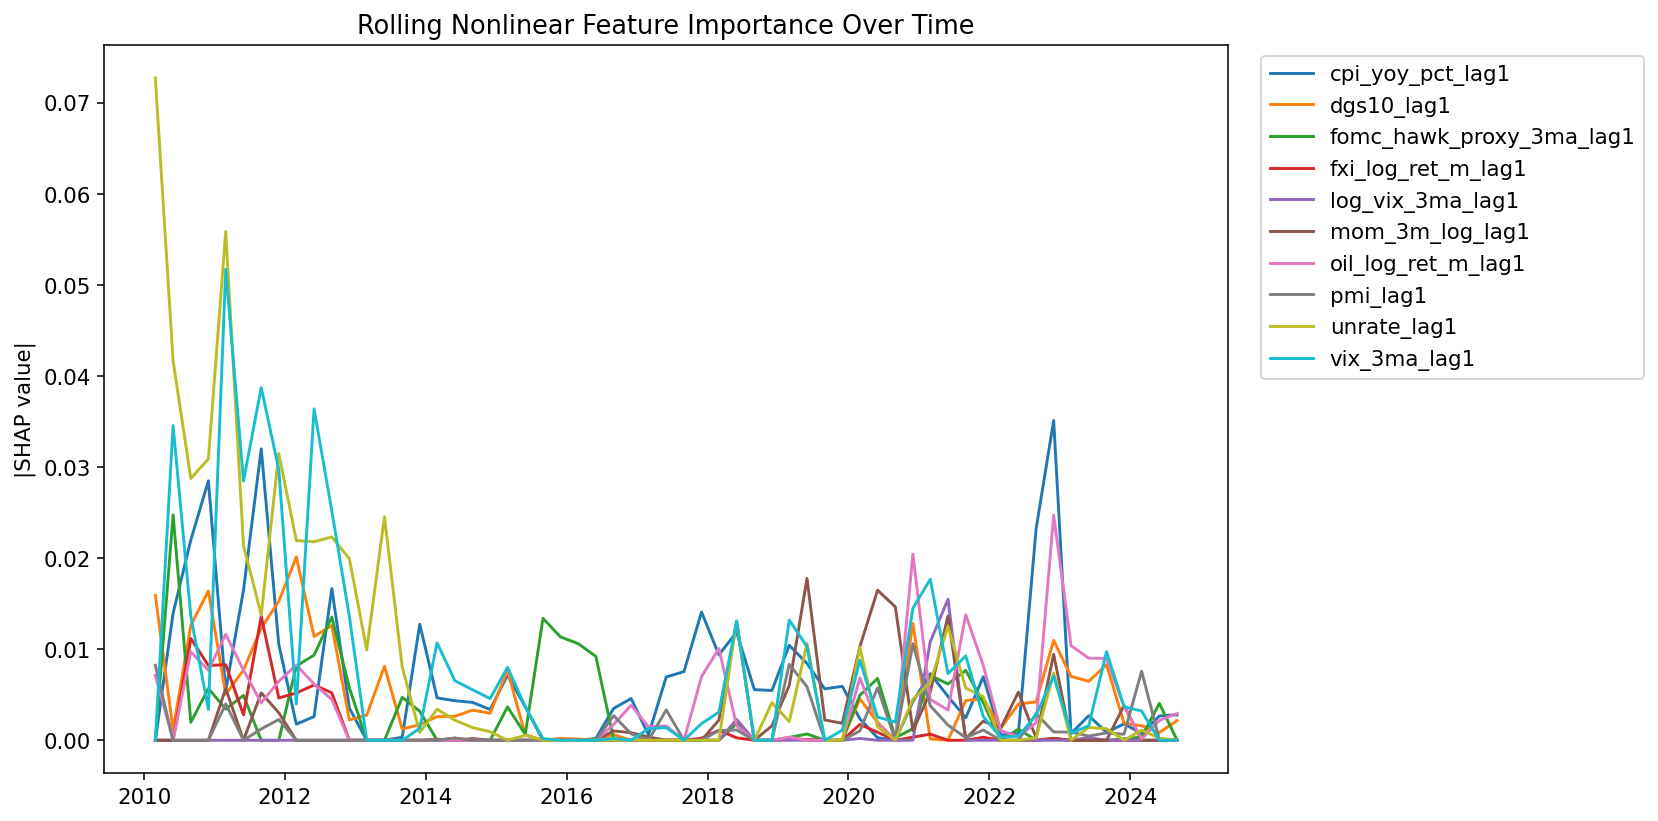

In [9]:
shap_long = shap_df.melt(
    id_vars="month_end",
    var_name="feature",
    value_name="shap_value"
)

shap_long["abs_shap"] = shap_long["shap_value"].abs()

print(shap_long.head())
print(shap_long.shape)

# compute average absolute SHAP importance

avg_shap = (
    shap_long.groupby("feature", as_index=False)["abs_shap"]
    .mean()
    .sort_values("abs_shap", ascending=False)
)

print(avg_shap)

# bar plot of average absolute SHAP values
plt.figure(figsize=(8, 5))
plt.bar(avg_shap["feature"], avg_shap["abs_shap"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean |SHAP value|")
plt.title("Average Nonlinear Feature Importance")
plt.tight_layout()
plt.show()

# time-varying plot of SHAP values 
shap_time = shap_long.pivot(
    index="month_end",
    columns="feature",
    values="abs_shap"
)

plt.figure(figsize=(12, 6))
for col in shap_time.columns:
    plt.plot(shap_time.index, shap_time[col], label=col)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylabel("|SHAP value|")
plt.title("Rolling Nonlinear Feature Importance Over Time")
plt.tight_layout()
plt.show()

In [10]:
# Evaluation metrics

def metric_block(actual, pred):
    mask = pd.notna(actual) & pd.notna(pred)
    y = np.asarray(actual[mask])
    p = np.asarray(pred[mask])

    return {
        "RMSE": np.sqrt(mean_squared_error(y, p)),
        "MAE": mean_absolute_error(y, p),
        "Directional_Accuracy": sign_accuracy(y, p),
        "N_Predictions": len(y)
    }

metric_rows = []

for col, label in [
    ("pred_mean", "Historical Mean"),
    ("pred_mom_lr", "Momentum-only LR"),
    ("pred_enet", "Rolling Elastic Net"),
    ("pred_tree", "Rolling Tree Model"),
]:
    m = metric_block(rolling_preds["actual"], rolling_preds[col])
    m["Model"] = label
    metric_rows.append(m)

metrics_df = pd.DataFrame(metric_rows)[
    ["Model", "RMSE", "MAE", "Directional_Accuracy", "N_Predictions"]
].sort_values("RMSE").reset_index(drop=True)

print(metrics_df)

                 Model      RMSE       MAE  Directional_Accuracy  \
0   Rolling Tree Model  0.051050  0.043041              0.745763   
1  Rolling Elastic Net  0.051601  0.041645              0.813559   
2      Historical Mean  0.055678  0.043151              0.745763   
3     Momentum-only LR  0.057449  0.045956              0.728814   

   N_Predictions  
0             59  
1             59  
2             59  
3             59  


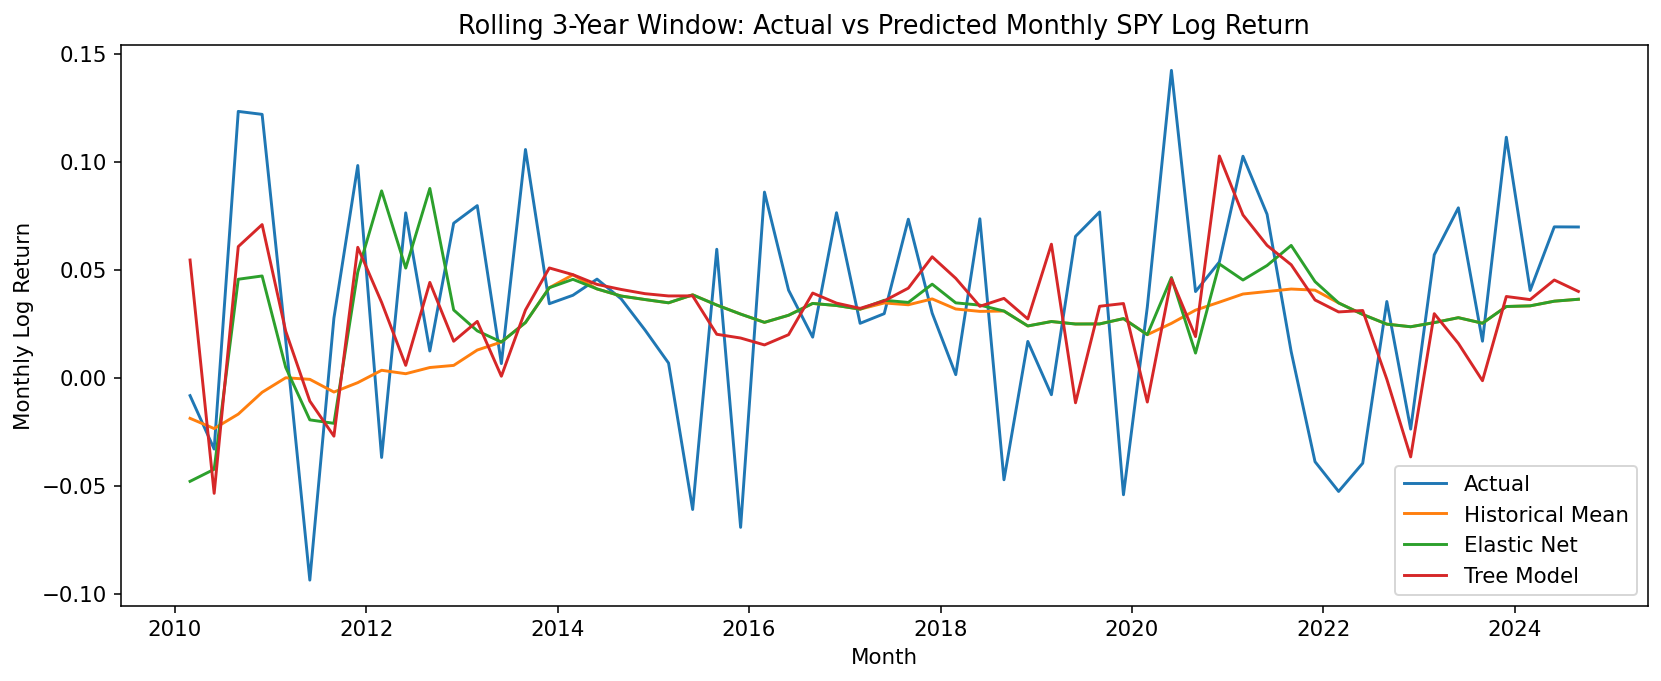

Saved: figures/rolling_predictions_actual_vs_models.png


In [11]:
# Actual vs predicted

plt.figure(figsize=(12, 5))
plt.plot(rolling_preds["month_end"], rolling_preds["actual"], label="Actual")
plt.plot(rolling_preds["month_end"], rolling_preds["pred_mean"], label="Historical Mean")
plt.plot(rolling_preds["month_end"], rolling_preds["pred_enet"], label="Elastic Net")
plt.plot(rolling_preds["month_end"], rolling_preds["pred_tree"], label="Tree Model")

plt.title("Rolling 3-Year Window: Actual vs Predicted Monthly SPY Log Return")
plt.xlabel("Month")
plt.ylabel("Monthly Log Return")
plt.legend()
plt.tight_layout()

outpath = os.path.join(OUTDIR, "rolling_predictions_actual_vs_models.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)

In [12]:
# Readable feature labels

pretty_names = {
    "mom_3m_log_lag1": "3-Month Momentum",
    "vix_m_lag1": "VIX Level",
    "log_vix_m_lag1": "Log VIX",
    "vix_3ma_lag1": "VIX Level (3M Avg)",
    "log_vix_3ma_lag1": "Log VIX (3M Avg)",
    "fxi_log_ret_m_lag1": "China Equity Returns (FXI)",
    "oil_log_ret_m_lag1": "Oil Returns",
    "fomc_hawk_proxy_m_lag1": "FOMC Hawkishness",
    "fomc_hawk_proxy_3ma_lag1": "FOMC Hawkishness (3M Avg)",
    "cpi_yoy_pct_lag1": "Inflation (CPI YoY)",
    "unrate_lag1": "Unemployment Rate",
    "dgs10_lag1": "10Y Treasury Yield",
    "pmi_lag1": "Manufacturing PMI",
}

def pretty_feature_name(x):
    return pretty_names.get(x, x)

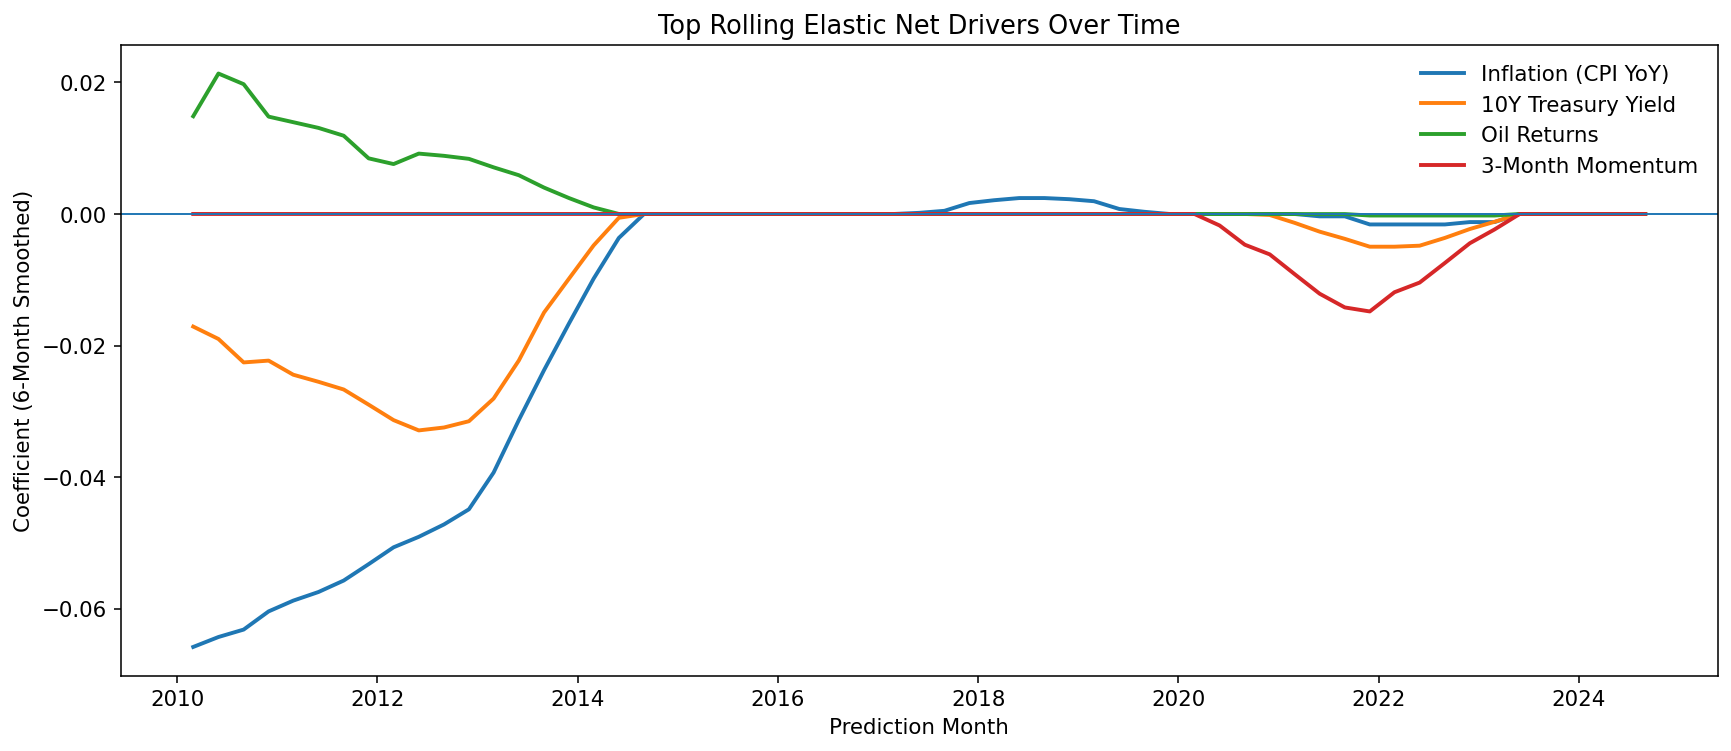

Saved: figures/rolling_enet_top_drivers_lines.png


In [13]:
# Top Elastic Net drivers over time (line plot)

coef_plot = coef_df.copy()

if len(coef_plot) > 0:
    coef_plot["month_end"] = pd.to_datetime(coef_plot["month_end"])
    coef_plot = coef_plot.sort_values("month_end").set_index("month_end")

    coef_features = [c for c in feature_cols if c in coef_plot.columns]
    coef_features = [
        c for c in coef_features
        if coef_plot[c].notna().sum() > 0 and coef_plot[c].abs().sum() > 0
    ]

    coef_mat = coef_plot[coef_features].copy()

    # smooth to reduce noise
    coef_smooth = coef_mat.rolling(window=6, min_periods=1).mean()

    # choose top 4 most important features overall
    top_features = (
        coef_smooth.abs().mean()
        .sort_values(ascending=False)
        .head(4)
        .index.tolist()
    )

    plt.figure(figsize=(12.5, 5.5))

    for f in top_features:
        plt.plot(
            coef_smooth.index,
            coef_smooth[f],
            linewidth=2,
            label=pretty_feature_name(f)
        )

    plt.axhline(0, linewidth=1)
    plt.title("Top Rolling Elastic Net Drivers Over Time")
    plt.xlabel("Prediction Month")
    plt.ylabel("Coefficient (6-Month Smoothed)")
    plt.legend(frameon=False)
    plt.tight_layout()

    outpath = os.path.join(OUTDIR, "rolling_enet_top_drivers_lines.png")
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", outpath)
else:
    print("No coefficient data available.")

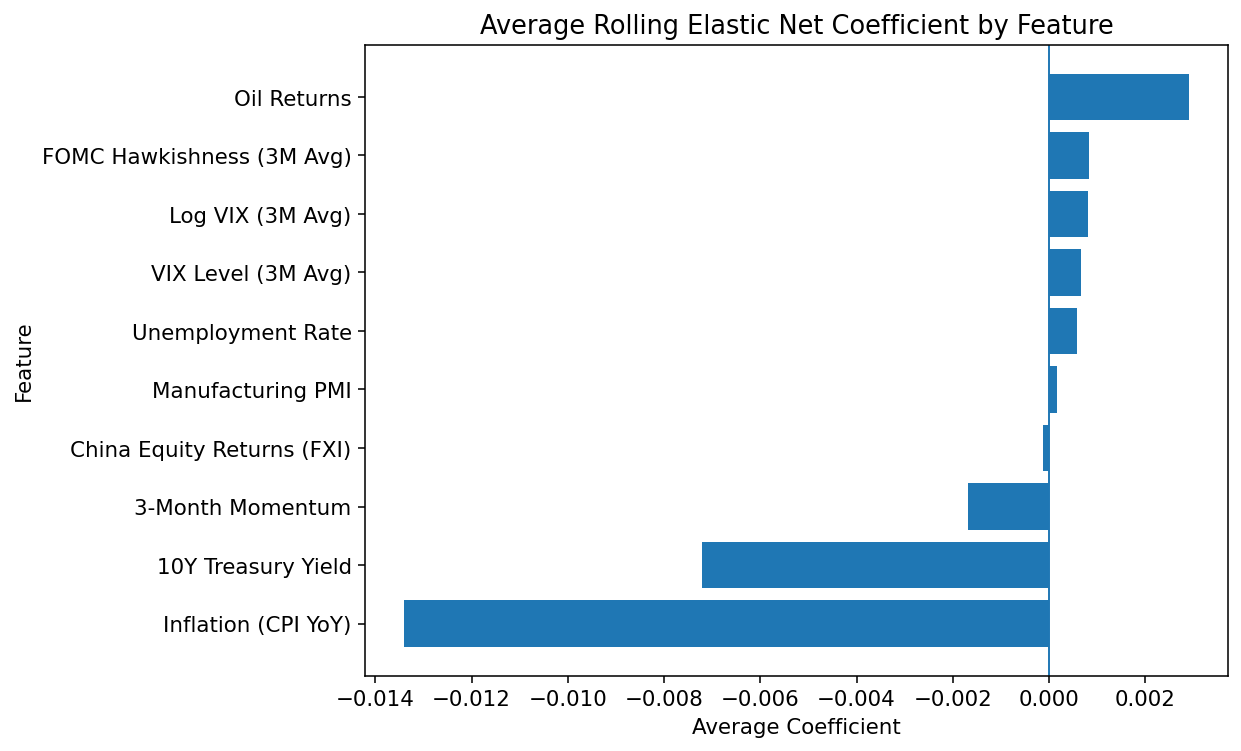

Saved: figures/rolling_enet_avg_coefficient_bar.png


In [14]:
# Average coefficient by feature (bar chart)

coef_plot = coef_df.copy()

if len(coef_plot) > 0:
    coef_plot["month_end"] = pd.to_datetime(coef_plot["month_end"])
    coef_plot = coef_plot.sort_values("month_end").set_index("month_end")

    coef_features = [c for c in feature_cols if c in coef_plot.columns]
    coef_features = [
        c for c in coef_features
        if coef_plot[c].notna().sum() > 0 and coef_plot[c].abs().sum() > 0
    ]

    coef_smooth = coef_plot[coef_features].rolling(window=6, min_periods=1).mean()

    avg_coef = coef_smooth.mean().sort_values()
    labels = [pretty_feature_name(x) for x in avg_coef.index]

    plt.figure(figsize=(9, 5.5))
    plt.barh(labels, avg_coef.values)
    plt.axvline(0, linewidth=1)
    plt.title("Average Rolling Elastic Net Coefficient by Feature")
    plt.xlabel("Average Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()

    outpath = os.path.join(OUTDIR, "rolling_enet_avg_coefficient_bar.png")
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", outpath)
else:
    print("No coefficient data available.")

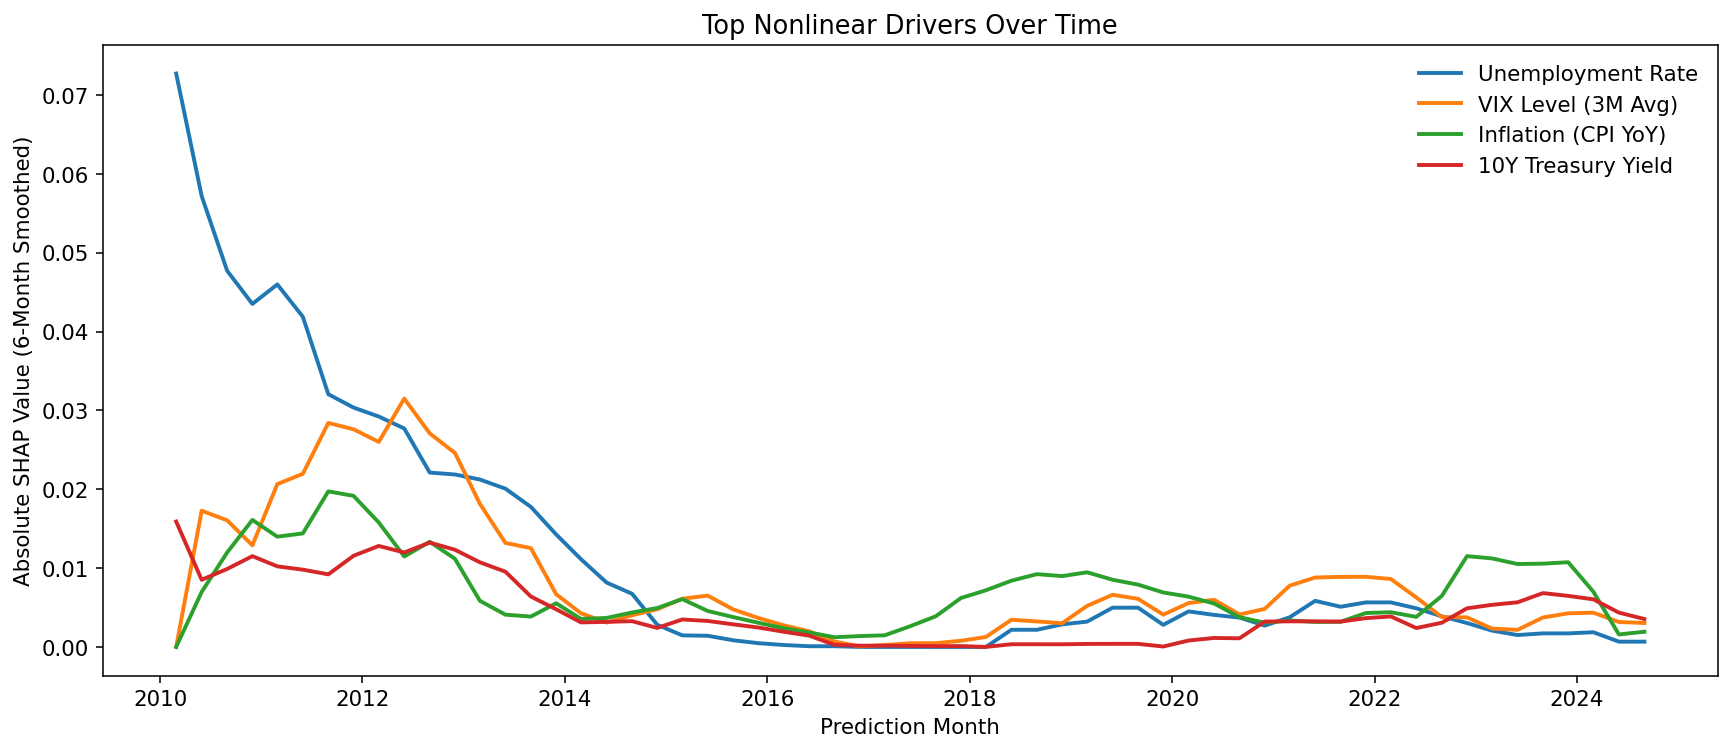

Saved: figures/rolling_shap_top_drivers_lines.png


In [15]:
# Top nonlinear driver importance over time (line plot)

shap_plot = shap_df.copy()

if len(shap_plot) > 0:
    shap_plot["month_end"] = pd.to_datetime(shap_plot["month_end"])
    shap_plot = shap_plot.sort_values("month_end").set_index("month_end")

    shap_features = [c for c in feature_cols if c in shap_plot.columns]
    shap_features = [
        c for c in shap_features
        if shap_plot[c].notna().sum() > 0 and shap_plot[c].abs().sum() > 0
    ]

    shap_abs = shap_plot[shap_features].abs().copy()
    shap_smooth = shap_abs.rolling(window=6, min_periods=1).mean()

    top_shap_features = (
        shap_smooth.mean()
        .sort_values(ascending=False)
        .head(4)
        .index.tolist()
    )

    plt.figure(figsize=(12.5, 5.5))

    for f in top_shap_features:
        plt.plot(
            shap_smooth.index,
            shap_smooth[f],
            linewidth=2,
            label=pretty_feature_name(f)
        )

    plt.title("Top Nonlinear Drivers Over Time")
    plt.xlabel("Prediction Month")
    plt.ylabel("Absolute SHAP Value (6-Month Smoothed)")
    plt.legend(frameon=False)
    plt.tight_layout()

    outpath = os.path.join(OUTDIR, "rolling_shap_top_drivers_lines.png")
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", outpath)
else:
    print("No SHAP data available.")

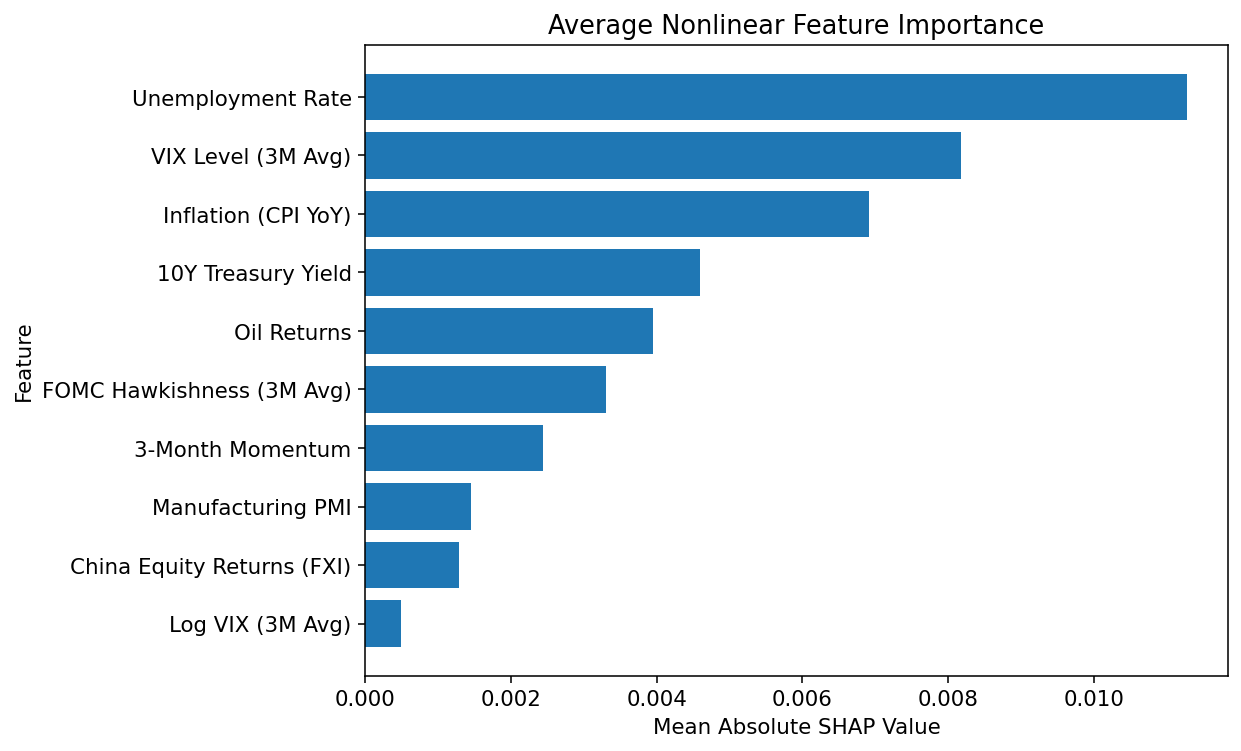

Saved: figures/avg_abs_shap_bar_readable.png


In [16]:
# Overall SHAP importance bar chart

if len(shap_df) > 0:
    shap_plot = shap_df.copy()
    shap_plot["month_end"] = pd.to_datetime(shap_plot["month_end"])
    shap_plot = shap_plot.sort_values("month_end").set_index("month_end")

    shap_features = [c for c in feature_cols if c in shap_plot.columns]
    shap_features = [
        c for c in shap_features
        if shap_plot[c].notna().sum() > 0 and shap_plot[c].abs().sum() > 0
    ]

    shap_smooth = shap_plot[shap_features].abs().rolling(window=6, min_periods=1).mean()
    shap_rank = shap_smooth.mean().sort_values()

    labels = [pretty_feature_name(x) for x in shap_rank.index]

    plt.figure(figsize=(9, 5.5))
    plt.barh(labels, shap_rank.values)
    plt.title("Average Nonlinear Feature Importance")
    plt.xlabel("Mean Absolute SHAP Value")
    plt.ylabel("Feature")
    plt.tight_layout()

    outpath = os.path.join(OUTDIR, "avg_abs_shap_bar_readable.png")
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", outpath)
else:
    print("No SHAP data available.")

In [17]:
# Save metrics table as PNG

def save_table_png(df, title, path):
    show = df.copy()

    for c in show.columns:
        if pd.api.types.is_float_dtype(show[c]):
            show[c] = show[c].map(lambda x: f"{x:.4f}")

    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.axis("off")
    ax.set_title(title, pad=10, fontsize=13, fontweight="bold")

    tbl = ax.table(
        cellText=show.values,
        colLabels=list(show.columns),
        cellLoc="center",
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.4)

    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path)

metrics_path = os.path.join(OUTDIR, "rolling_model_metrics_table.png")
save_table_png(metrics_df, "Out-of-Sample Performance — Rolling 3-Year Window", metrics_path)

Saved: figures/rolling_model_metrics_table.png
